<a href="https://colab.research.google.com/github/fralfaro/MAT306/blob/main/docs/labs/lab_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MAT306 - Laboratorio N°05





**Objetivo**: Explorar y visualizar datos de Netflix usando **matplotlib** y **seaborn/plotly**, aprendiendo a elegir gráficos adecuados para distintos tipos de variables y preguntas de análisis.



**Dataset**:

Trabajaremos con el archivo `netflix_titles.csv`, que contiene información sobre los títulos disponibles en la plataforma Netflix hasta el año 2021.

| Variable       | Clase     | Descripción                                                                 |
|----------------|-----------|------------------------------------------------------------------------------|
| show_id        | caracter  | Identificador único del título en el catálogo de Netflix.                   |
| type           | caracter  | Tipo de contenido: 'Movie' o 'TV Show'.                                     |
| title          | caracter  | Título del contenido.                                                       |
| director       | caracter  | Nombre del director (puede ser nulo).                                       |
| cast           | caracter  | Lista de actores principales (puede ser nulo).                              |
| country        | caracter  | País o países donde se produjo el contenido.                                |
| date_added     | fecha     | Fecha en la que el título fue agregado al catálogo de Netflix.              |
| release_year   | entero    | Año de lanzamiento original del título.                                     |
| rating         | caracter  | Clasificación por edad (por ejemplo: 'PG-13', 'TV-MA').                      |
| duration       | caracter  | Duración del contenido (minutos o número de temporadas para series).        |
| listed_in      | caracter  | Categorías o géneros en los que está clasificado el contenido.              |
| description    | caracter  | Breve sinopsis del contenido.                                               |




In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

sns.set_theme(style="whitegrid")

In [2]:
import pandas as pd

# Cargar datos
df = pd.read_csv('https://raw.githubusercontent.com/fralfaro/MAT306/main/docs/labs/data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 📊 Parte 1: Exploración visual básica

1. **Distribución de tipos de contenido**

   * Realiza un gráfico de barras mostrando la cantidad de películas vs series (`type`).
   * Pregunta guía: ¿Cuál es el tipo de contenido predominante en Netflix? ¿Qué implicancias podría tener para los usuarios?

2. **Histograma de años de lanzamiento**

   * Muestra cómo se distribuyen los títulos según su `release_year`.
   * Pregunta guía: ¿Hay más contenido reciente o antiguo? ¿Notas algún patrón en décadas específicas?

3. **Proporción de clasificaciones por edad (`rating`)**

   * Haz un gráfico circular o de barras.
   * Pregunta guía: ¿Qué clasificación es más común? ¿Crees que Netflix está más enfocado en público adulto, familiar o infantil?



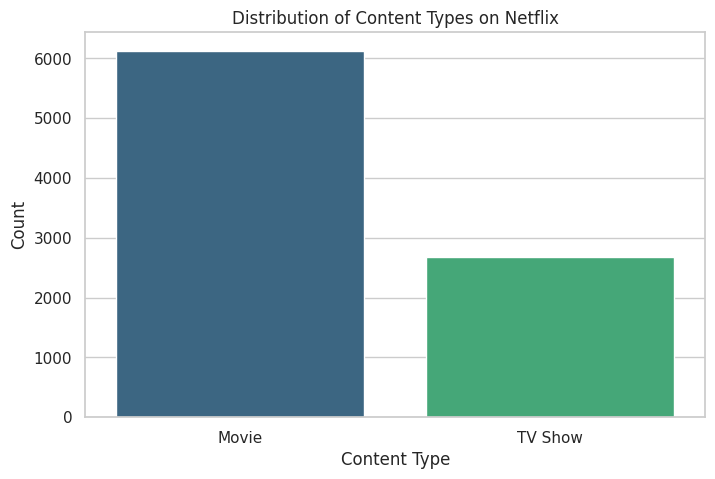

->>> El tipo mas predominante en Netfliz son las peliculas 



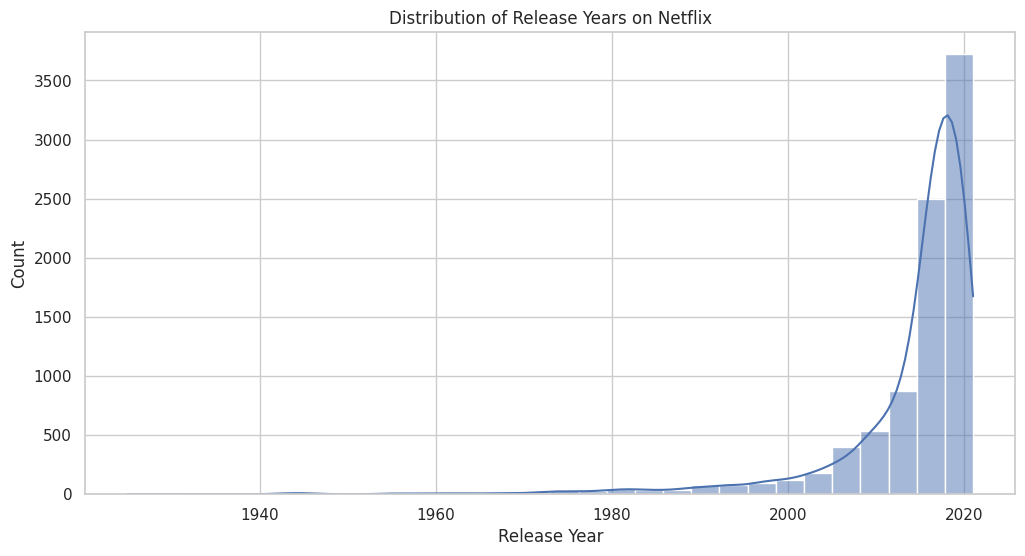

->>> Hay mucho mas contenido actual que antiguo, se ve hasta una tendencia exponencial, aun que en los ultimos años se ha ido estancando



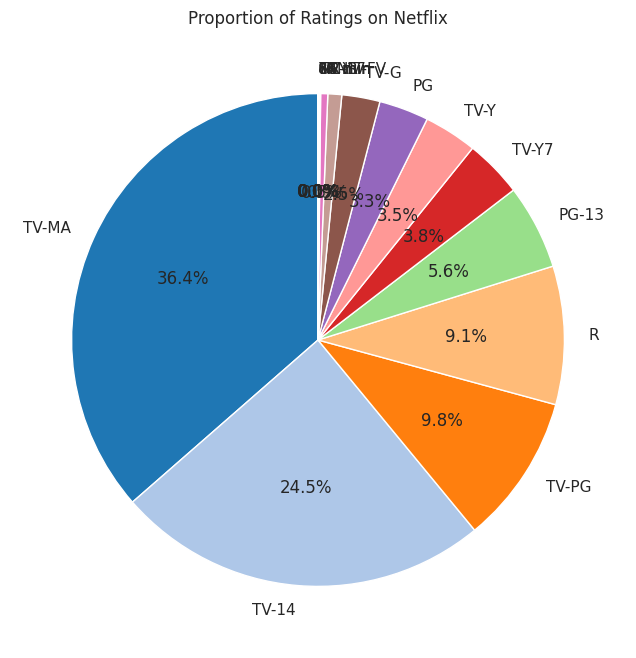

->>> Con mas de 1/3 de las peliculas de Netflix gana la clasificacion TV-MA, luego la TV-14, esto nos dice que Netflix no esta enfocado en niños si no en gente algo mas adulta.


In [15]:
warnings.filterwarnings("ignore")

# 1. Distribución de tipos de contenido
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='type', palette='viridis')
plt.title('Distribution of Content Types on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

print("->>> El tipo mas predominante en Netfliz son las peliculas \n")

# 2. Histograma de años de lanzamiento
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='release_year', bins=30, kde=True, palette='plasma')
plt.title('Distribution of Release Years on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

print("->>> Hay mucho mas contenido actual que antiguo, se ve hasta una tendencia exponencial, aun que en los ultimos años se ha ido estancando\n")

# 3. Proporción de clasificaciones por edad (rating)
plt.figure(figsize=(10, 8))
df['rating'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='tab20')
plt.title('Proportion of Ratings on Netflix')
plt.ylabel('')
plt.show()

print("->>> Con mas de 1/3 de las peliculas de Netflix gana la clasificacion TV-MA, luego la TV-14, esto nos dice que Netflix no esta enfocado en niños si no en gente algo mas adulta.")



## 🎨 Parte 2: Tendencias y evolución en el tiempo

4. **Número de títulos agregados por año**

   * Usa `date_added` (convertido a fecha) y grafica una serie temporal.
   * Pregunta guía: ¿Cuándo creció más el catálogo de Netflix? ¿Qué relación podría tener con la expansión internacional de la plataforma?

5. **Heatmap de lanzamientos por año y mes**

   * Construye un mapa de calor con `year_added` y `month_added`.
   * Pregunta guía: ¿Hay meses con más estrenos que otros? ¿Qué conclusiones puedes sacar sobre la estacionalidad de lanzamientos?

6. **Duración de películas por género**

   * Extrae la duración en minutos y crea un boxplot agrupado por género principal.
   * Pregunta guía: ¿Qué géneros suelen durar más? ¿Qué podrías decir sobre la variabilidad dentro de un mismo género?


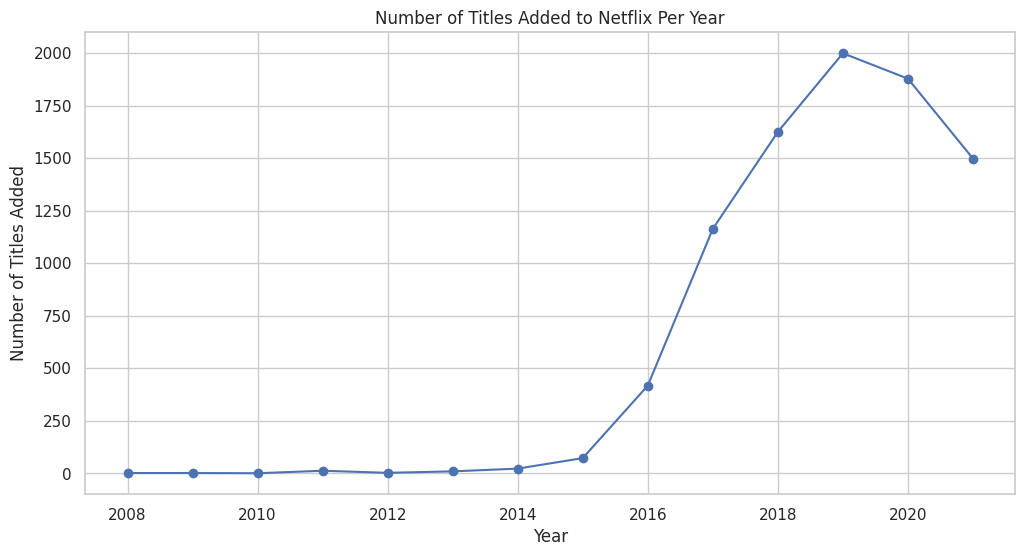

->>> ea agregaron mas cantidad de peliculas entre el año 20176 a 2017, esto esta totalmente relacionado al boom de streaming y el crecimiento de Netflix



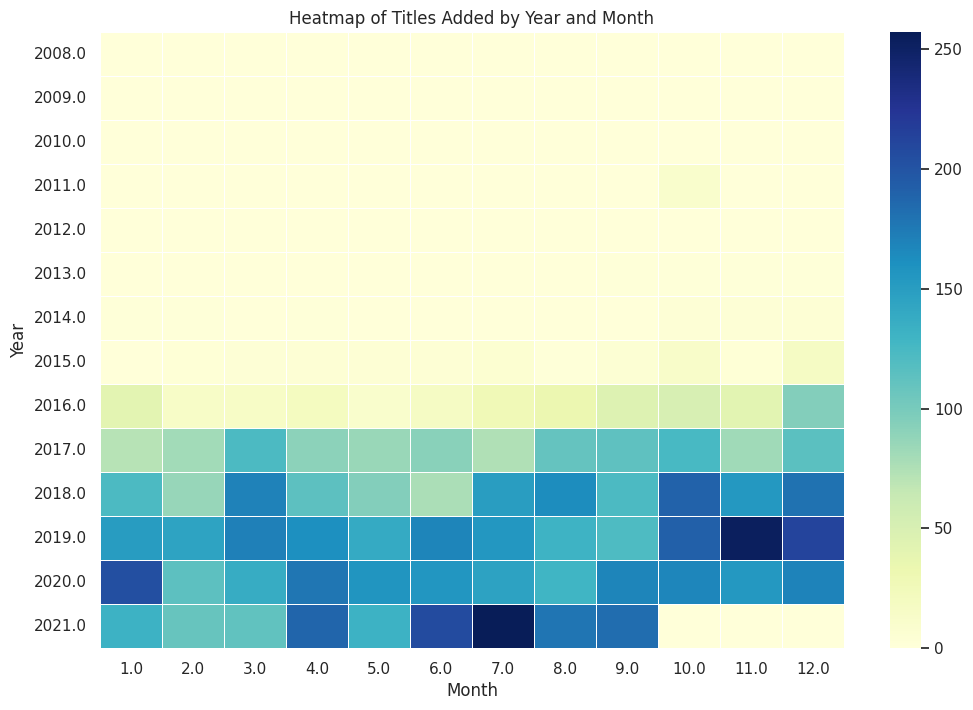

->>> No se puede inferir mucho de este grafico quizas es seguro decir que se estrenan mas peliculas en sel segundo semestre del año



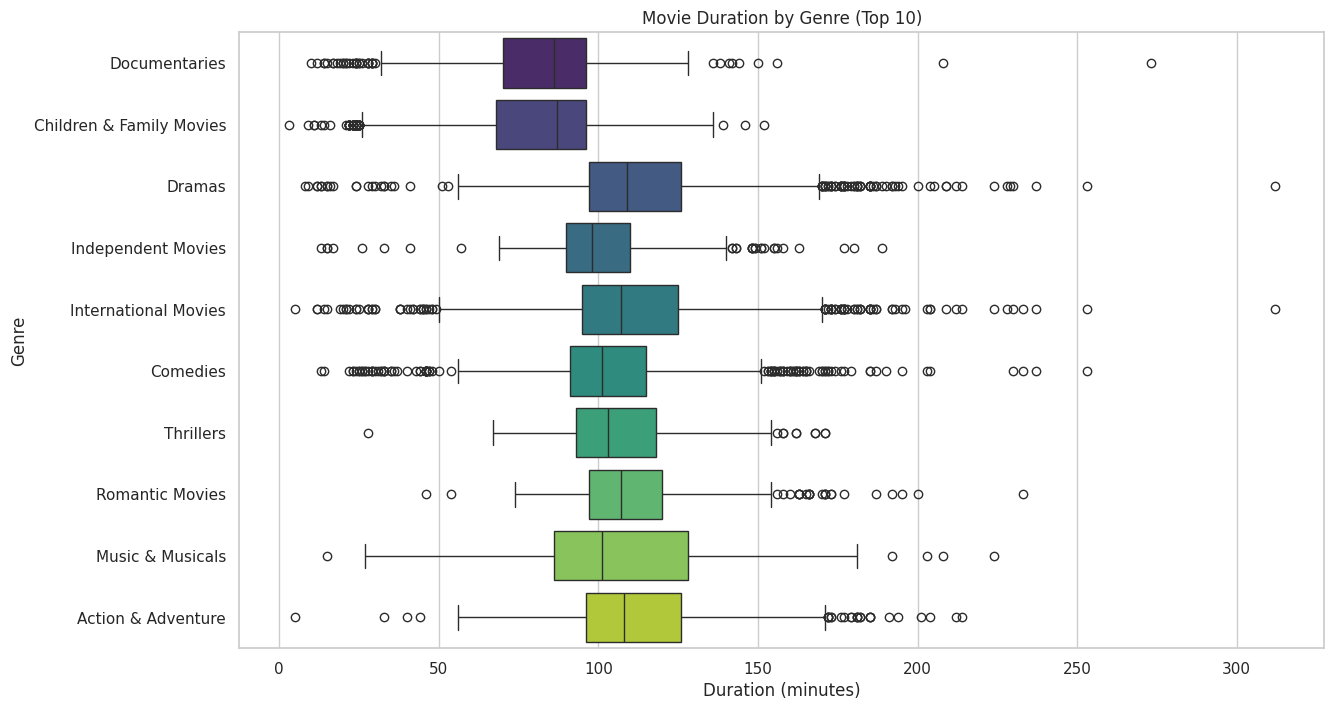

->>> Es bastante claro que las peliculas mas largos son las de genero: Dramas y Internacional movies


In [16]:
# 4.
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

titles_per_year = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
titles_per_year.plot(kind='line', marker='o')
plt.title('Number of Titles Added to Netflix Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(True)
plt.show()

print("->>> ea agregaron mas cantidad de peliculas entre el año 20176 a 2017, esto esta totalmente relacionado al boom de streaming y el crecimiento de Netflix\n")

# 5.
monthly_added = df.groupby(['year_added', 'month_added']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(monthly_added, cmap='YlGnBu', linewidths=.5)
plt.title('Heatmap of Titles Added by Year and Month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

print("->>> No se puede inferir mucho de este grafico quizas es seguro decir que se estrenan mas peliculas en sel segundo semestre del año\n")

# 6.
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_minutes'] = movies_df['duration'].str.replace(' min', '').astype(float)

# Split genres and explode the dataframe
genres_df = movies_df.assign(listed_in=movies_df['listed_in'].str.split(', ')).explode('listed_in')

# Consider only top N genres for clarity
top_genres = genres_df['listed_in'].value_counts().nlargest(10).index
genres_df_filtered = genres_df[genres_df['listed_in'].isin(top_genres)]

plt.figure(figsize=(14, 8))
sns.boxplot(data=genres_df_filtered, x='duration_minutes', y='listed_in', palette='viridis')
plt.title('Movie Duration by Genre (Top 10)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Genre')
plt.show()

print("->>> Es bastante claro que las peliculas mas largos son las de genero: Dramas y Internacional movies")



## 🔥 Parte 3: Comparaciones y relaciones

7. **Top 10 países con más producciones**

   * Usa un gráfico de barras para mostrar los países más frecuentes en la columna `country`.
   * Pregunta guía: ¿Qué países dominan el catálogo? ¿Sorprende la distribución o es esperada?

8. **Películas vs Series según género**

   * Realiza un gráfico de barras apiladas para mostrar la cantidad de títulos por género, separando `Movie` y `TV Show`.
   * Pregunta guía: ¿Existen géneros más asociados a películas o a series?

9. **Relación entre duración y año de lanzamiento**

   * Haz un gráfico de dispersión (scatterplot) con `release_year` en el eje X y `duration` (en minutos) en el eje Y.
   * Pregunta guía: ¿Han cambiado los estándares de duración de las películas con el tiempo? ¿Se ven outliers interesantes?



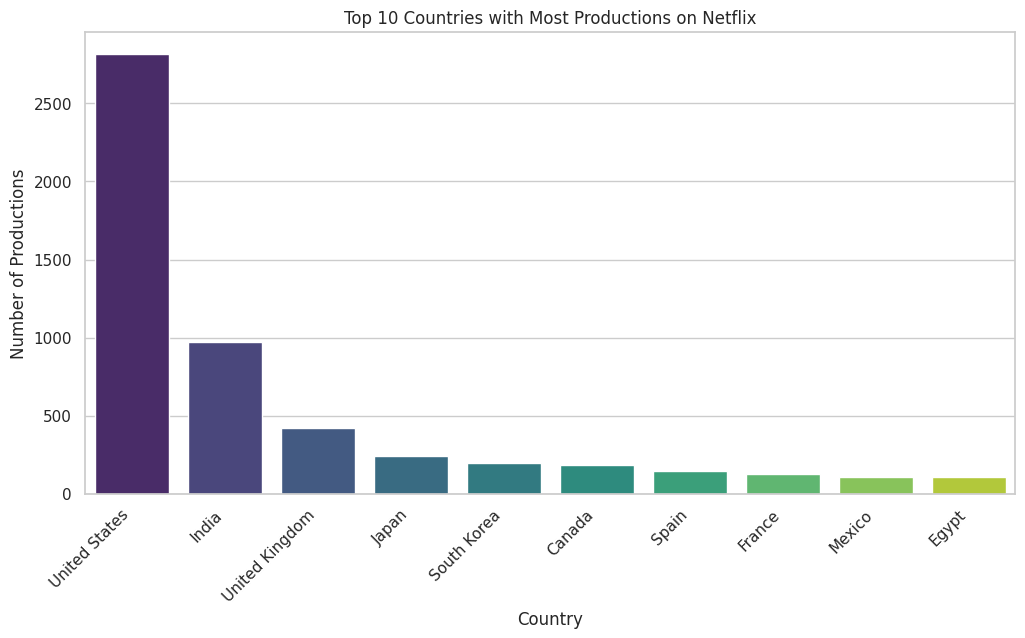

->>> USA e india lider, es bastante razonable ya que es donde estan las estudios cinematograficos mas grandes del mundo



<Figure size 1400x800 with 0 Axes>

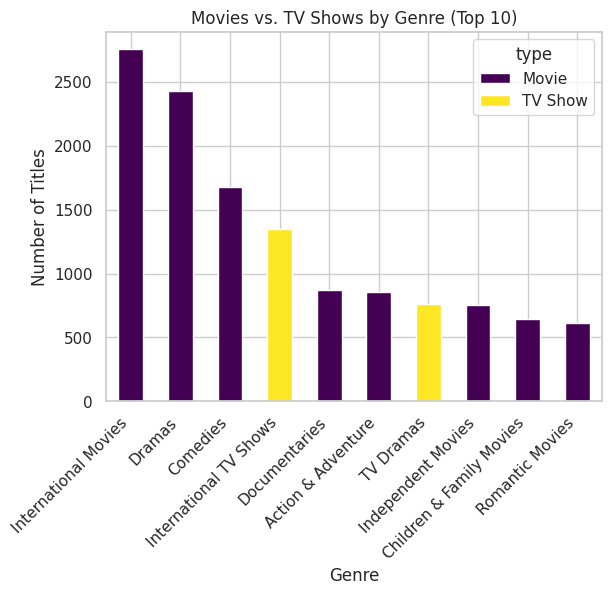

->>> Practicamente todos los generos estan mas asociados a peliculas menos International TV show y TV Dramas los cuales claramente estan diseñados para estar ser series de TV



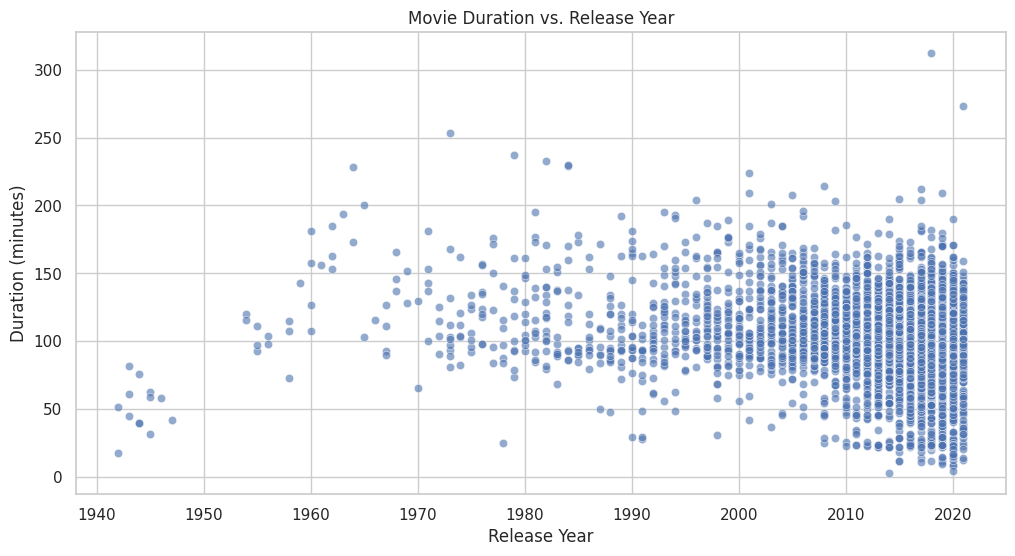

->>> Al inicio duraban muy poco luego fue convergiendo a un tiempo promedio de 150 minutos, aun que ultimamente el promedio a comenzado a bajar


In [18]:
# 7.
plt.figure(figsize=(12, 6))
country_counts = df['country'].value_counts().nlargest(10)
sns.barplot(x=country_counts.index, y=country_counts.values, palette='viridis')
plt.title('Top 10 Countries with Most Productions on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Productions')
plt.xticks(rotation=45, ha='right')
plt.show()

print("->>> USA e india lider, es bastante razonable ya que es donde estan las estudios cinematograficos mas grandes del mundo\n")

# 8.
genre_type_df = df.assign(listed_in=df['listed_in'].str.split(', ')).explode('listed_in')

# Group by genre and type and count
genre_type_counts = genre_type_df.groupby(['listed_in', 'type']).size().unstack(fill_value=0)

# Consider only top N genres for clarity
top_genres_type = genre_type_df['listed_in'].value_counts().nlargest(10).index
genre_type_counts_filtered = genre_type_counts.loc[top_genres_type]

plt.figure(figsize=(14, 8))
genre_type_counts_filtered.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Movies vs. TV Shows by Genre (Top 10)')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.show()

print("->>> Practicamente todos los generos estan mas asociados a peliculas menos International TV show y TV Dramas los cuales claramente estan diseñados para estar ser series de TV\n")

# 9.
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_minutes'] = movies_df['duration'].str.replace(' min', '').astype(float)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=movies_df, x='release_year', y='duration_minutes', alpha=0.6)
plt.title('Movie Duration vs. Release Year')
plt.xlabel('Release Year')
plt.ylabel('Duration (minutes)')
plt.show()

print("->>> Al inicio duraban muy poco luego fue convergiendo a un tiempo promedio de 150 minutos, aun que ultimamente el promedio a comenzado a bajar")

## ⭐ Desafío Final

* Encuentra las combinaciones más frecuentes de **género + rating** y represéntalas en un **heatmap o gráfico de burbujas**.
* Pregunta guía: ¿Qué géneros están más dirigidos a un público adulto? ¿Y cuáles a público familiar o infantil?

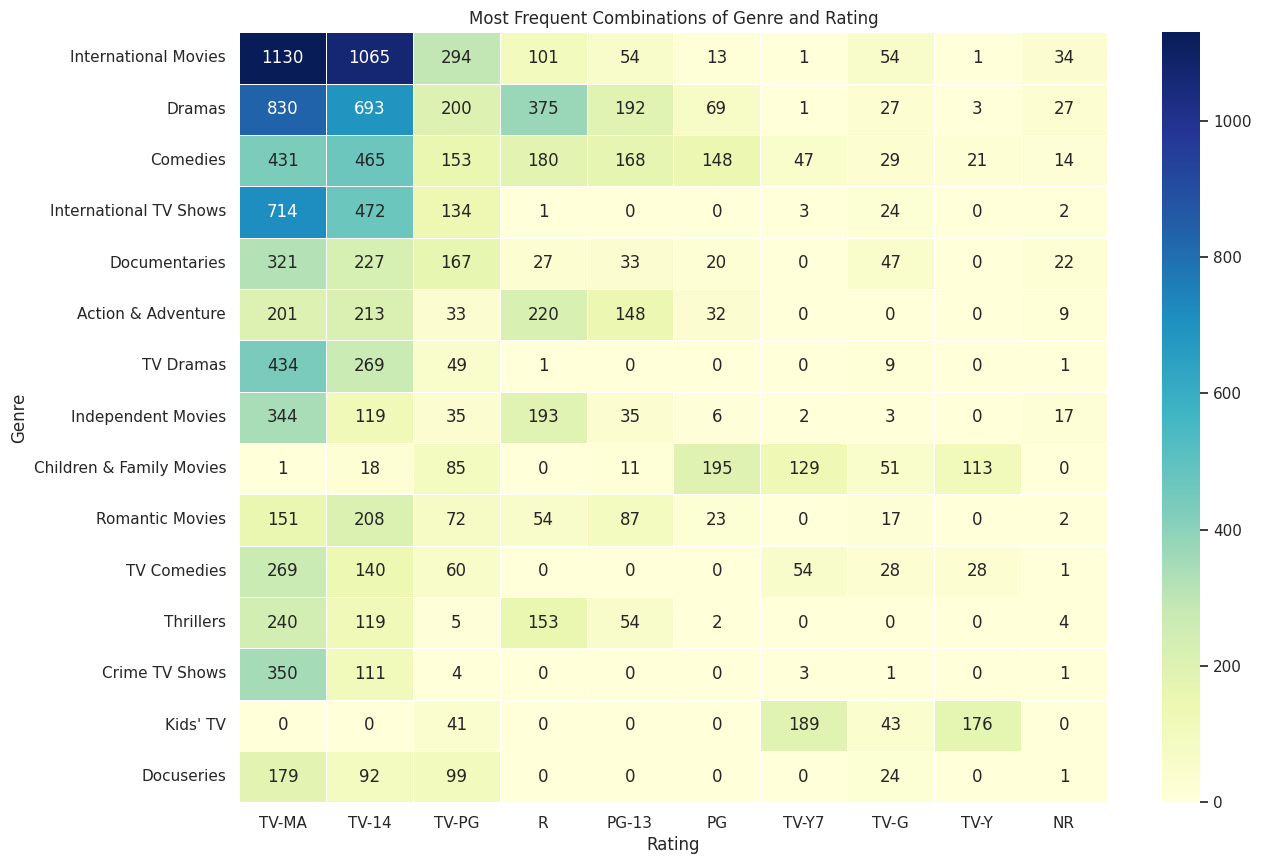

->>> El genero preferido para adultos son las International Movies, aun que no podemos decidir basados en este heatmap cual sera el genero preferido para familias ni niños 


In [20]:
genre_df = df.assign(listed_in=df['listed_in'].str.split(', ')).explode('listed_in')
genre_rating_df = genre_df.dropna(subset=['rating', 'listed_in'])
genre_rating_counts = genre_rating_df.groupby(['listed_in', 'rating']).size().unstack(fill_value=0)
top_genres = genre_rating_df['listed_in'].value_counts().nlargest(15).index
genre_rating_counts_filtered = genre_rating_counts.loc[top_genres]
top_ratings = genre_rating_df['rating'].value_counts().nlargest(10).index
genre_rating_counts_filtered = genre_rating_counts_filtered[top_ratings]

# Create a heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(genre_rating_counts_filtered, cmap='YlGnBu', annot=True, fmt='d', linewidths=.5)
plt.title('Most Frequent Combinations of Genre and Rating')
plt.xlabel('Rating')
plt.ylabel('Genre')
plt.show()
print("->>> El genero preferido para adultos son las International Movies, aun que no podemos decidir basados en este heatmap cual sera el genero preferido para familias ni niños ")